## Creating a Logistic Regression Model

### Discovery

Welcome new data analyst contractor, to day 2 at Ethical Oil Inc! The humble management team were incredibly impressed with your previous efforts in creating a linear regression model to demonstrate how the close price of the S&P 500 will impact the price of oil. <br><br>
They would now like you to take this knowledge even further and would like you to understand if it's possible to predict whether the cost of oil will reach a certain threshold. Being the ever intelligent and resourceful contractor that you are, you know that you can do this with logistic regression, but have overpromised and said you will deliver them the model today, in exchange for additional paid leave. Happily, the data has already been loaded and transformed from your earlier efforts and you will just need to build the model and analyse the results. 

First we will import the required modules. They are:
- pandas
- seaborn
- statsmodels.api
- sklearn.model_selection - train_test_split
- sklearn.metrics - confusion_matrix
- matplotlib.pyplot

In [13]:
# Import required modules
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt

--- 
### Data preparation
All data cleaning steps are identical to the steps taken for Linear Regression, as we are using the same dataset. We begin by importing the stocks dataset. Set the index column as the "Date". Remember to validate the import has worked.

In [14]:
# Import the first dataset and set the date as the index
stock_df = pd.read_csv("all_stocks_5yr.csv", index_col="Date", parse_dates=True, date_format="%d%m/%Y")
stock_df = stock_df[["Close"]]
stock_df = stock_df.rename(columns={'Close': 'S&P Close Price $'})
stock_df

,S&P Close Price $
Date,
01/02/2013,58.106483
01/03/2013,59.531515
01/04/2013,60.294833
01/05/2013,63.284582
01/06/2013,61.994978
...,...
01/10/2017,102.908070
01/11/2017,104.014336
01/12/2017,106.488189


Import the oil dataset, set the index column as "date". Remember to validate the import has worked. 

In [15]:
# Import the second dataset and set the date as the index
oil_df = pd.read_csv("crude-oil-price.csv", index_col="date", parse_dates=True, date_format="%d%m/%Y")
oil_df = oil_df[["price"]]
oil_df = oil_df.rename(columns={'price': 'Oil Cost $ (Barrell)'})
oil_df

,Oil Cost $ (Barrell)
date,
01/03/1983,29.2700
01/04/1983,30.6300
01/05/1983,30.2500
01/06/1983,31.3800
01/07/1983,32.0000
...,...
01/05/2025,60.7900
01/06/2025,65.1100
01/07/2025,69.2600


Create a new dataframe - restricting the oil data to rows (dates) that overlap between the stock and oil datasets only. 

Combine the two datasets together. You should end up with 61 rows of data, and all columns, from both dataframes in the same dataframe. Use an inner join.

In [16]:
# Combine both dataframes together using an inner join. 
join_df = oil_df.join(stock_df, how="inner")
join_df

,Oil Cost $ (Barrell),S&P Close Price $
01/02/2013,92.05,58.106483
01/03/2013,97.23,59.531515
01/04/2013,93.46,60.294833
01/05/2013,91.97,63.284582
01/06/2013,96.56,61.994978
...,...,...
01/10/2017,54.38,102.908070
01/11/2017,57.40,104.014336
01/12/2017,60.42,106.488189
01/01/2018,64.73,111.778353


In [17]:
# Check the dataset contains numeric values and equal rows. 
join_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 61 entries, 01/02/2013 to 01/02/2018
Data columns (total 2 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Oil Cost $ (Barrell)  61 non-null     float64
 1   S&P Close Price $     61 non-null     float64
dtypes: float64(2)
memory usage: 1.4+ KB


--- 
### Model planning
We can begin to explore our data by looking at the average values for our dependent (output) variable, which will help us to understand what the distribution of data may look like.

In [ ]:
# Get the mean and median prices from the dataset and print them in a single line of code. 

Next we want to create a histogram to understand the distribution of price, to understand what high prices might look like. Once we have this, we can create a binary field in our dataset, showing us whether we have hit the threshold or not. 

In [ ]:
# Create a histogram to determine a suitable threshold for high oil costs. 

Our histogram has a positive (right) skew and is bimodal. We can see the distribution of oil costs has two clear clusters. The main cluster (left) which has typically has a range of $45-$65, and second cluster (right) which has a range of $90-$110. With the main cluster containing the majority of our data, and with an outlier in $80, per barrell we can determine high costs of oil will be where oil costs $90 or more. This is where we will set our threshold for a True outcome. 

In [ ]:
# Create a new binary column in the dataframe which will be True/False based on the threshold. 

Now we can determine which variables will help us to determine if we will hit this threshold or not. We will first create a table, aggregating our dataset by our binary column. I'll use this to calculate the mean of each binary outcome. 

Next create a box plot to visualise the distribution of data, in cases where we hit our threshold, compared with where we don't. We are looking for clear differences, and minimal overlap between our True and False groups. 

In [ ]:
# Create a box plot to show the differences in distribution between your true and false groups. 

Finally, a correlation matrix will help us to see if there is a strong relationship between our dependent (output) variable and our binary independent (input) variable. 

In [ ]:
# Create a correlation matrix to demonstrate relationships between our variables. 

---
### Building the model

Building the data model is almost exactly the same as the process for Linear Regression. First, we split our data into training and test datasets. We set out dependent (output) variable, this time as our binary field. We then set our independent (input) variable, add the constant, and feed them both into the model function. This time, instead of using an OLS function, we will be using a Logit function. 

In [ ]:
# Split the data into train and test samples
train, test = train_test_split(join_df,random_state=25)

Set both the independent variable and dependent variable - remember to check they are set correctly. Don't forget to add a constant to your independent variables. 

In [ ]:
# Set the dependent variable and validate
dep = train["High Oil Cost $ (Barrell)"]
dep.head()

In [ ]:
# Set the independent variable and validate
ind = train["S&P Close Price $"]
ind.head()

In [ ]:
# Remember to add the constant 
ind = sm.add_constant(ind)
ind.head()

Now generate the logistic regression model along with a summary output. 

In [ ]:
# Fit the model and produce the summary
model = sm.Logit(dep,ind).fit()
model.summary()

--- 
### Communicating the results. 
You will now analyse the model and communicate the results. What do the following outputs tell you about the model

- Pseudo R-Squared: Best used to check the goodness of fit, when comparing models. Pseudo R-Squared does not account for variance. 
- P-Value: When below 0.05, we infer the independent variable is deemed to have a significant relationship with the dependent varaible. 
- Coefficient: In our case the independent variable coefficient is negative. This means as increase the independent variable, the log-odds, and therefore the likelihood of a positive outcome is reduced. 

---
#### The Math (for context)

We multiply the units of 'S&P Close Price $' by Eulers number, to the power of the coefficient value. 
<br> Euler's number (Constant) = 2.71828
<br> Coefficient = -0.7281

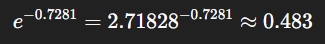

This means, for every unit the 'S&P Close Price' the odds of 'High Oil Cost' is multiplied by 0.483 - meaning the odds of having a positive result falls by approximately 51.7%:

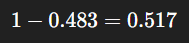

--- 

In [ ]:
# Use the model to predict which dates we are likely to hit high oil prices. Check the output. 


Once we have our preductions - we can use these to create a confusion matrix, which will help us to assess the model quality. 

In [ ]:
# Generate a confusion matrix to test the model.

# (Optional) Generate the confusion matrix as a heatmap

# (Optional) set x and y labels, and create a title

**Basic Terminology**

**True Positives (TP)** is __ : The model correctly predicted a large purchase. (Bottom right)

**True Negatives (TN)** is __ :The model correctly predicted that it wont be a large purchase. (Top left)

**False Positives (FP)** is __ : The model incorrectly predicted a large purchase. (Top right)

**False Negatives (FN)** is __ : The model incorrectly predicted it wont be a large purchase. (Bottom left)

The model was correct in __ + __ = __ cases; 

The model was incorrect in __ cases. 

Total = __ cases

__ / __ * 100 = __% accuracy

In [ ]:
# Format floats to return values to a maximum of x decimal places 
pd.set_option('display.float_format', '{:.10f}'.format) 

# Check incorrectly predicted rows


# Concert outputs to dataframe columns for comparison


# Check model accurate (or inaccurate) predictions


In [ ]:
# Test the model 

# Produce the output and save to a dataframe column - then validate

# (Optional) Create a dataframe where only incorrect predictions are displayed


In [ ]:
# Create a confusion matrix to display test results

# (Optional) Replicate the results as a heatmap as before:

# (Optional) set x and y labels, and create a title

--- 
### Operationalise
In the real world, this is where you would draft a report, deliver briefings, implement with automation on production level servers, produce technical documentation and build this into your BAU process. This being a fictional company, the ever grateful management have granted you paid leave for all your hard work and have volunteered to take on this burden themselves. Congratulations and well done!

--- 
### Stretch Tasks

By this stage, you have done everything required for CPD, but you can go further in your exploration of data, and analysis of the model. In this section we will:
- Produce a table of aggregates to look at the mean values for our 
- Create a histogram with the continuous probability density curve
- Create a Receiver Operating Characteristic (ROC) curve, which is used to plot the True Positives, against the False positives.


In [ ]:
# Create aggregate table on the true/false column. Find the mean value. Variables should have distinct differences in the mean.
join_df.groupby("High Oil Cost $ (Barrell)").mean()

In [ ]:
# Optional stylised output with a KDE... "...KDE represents the data using a continuous probability density curve in one or more dimensions".
# Fig represents the overall plot area, whereas ax represents everythinf cont
fig, ax = plt.subplots(figsize=(10,5))
plt.grid(visible = True, linestyle = "-",linewidth = 0.5, color = "grey")

sns.histplot(
    x="Oil Cost $ (Barrell)",
    data=join_df,
    color="#8FB2FF",
    bins=20,
    edgecolor="White",
    stat="density",
    ax=ax
)

sns.kdeplot(
    x="Oil Cost $ (Barrell)",
    data=join_df,
    color="grey",
    linewidth=1.5,
    ax=ax
)

ax.set_ylabel("Volume")
ax.set_title("Histogram showing distribution of oil cost")
plt.show()

In [ ]:
# Calculate the false positive rate (fpr), true positive rate (tpr) and thesholds whereby the model will predict a true positive.
fpr, tpr, thresholds = roc_curve(dep_test, y_score)


# Validate they have been calculated correctly
print(fpr)
print(tpr)
print(thresholds)

In [ ]:
# Calculate the area under curve (AUC) using the sklearn metric. 
roc_auc = auc(fpr, tpr)
print(f'The area under curve is calculated as {roc_auc}')

In [ ]:
# Put the data into a dataframe, ready for visualisation. Then validate
roc_df = pd.DataFrame({
    "False Positive Rate": fpr,
    "True Positive Rate": tpr
})
roc_df.head()

In [ ]:
# Plot the ROC curve
sns.lineplot(x="False Positive Rate",
             y="True Positive Rate",
             data=roc_df,
             label=f"ROC curve (AUC = {roc_auc:.3f})")

# Diagonal baseline
sns.lineplot(
    x=[0, 1],
    y=[0, 1],
    linestyle=":",
    label="Random classifier"
)

plt.title("ROC Curve")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.show()